# Exercise 2: The Plain English Guide
Hello! If you are confused by the assignment, let's break it down into very simple terms.

### What is the goal of this assignment?
In Exercise 1, you used a classic Machine Learning algorithm called an **SVM (Support Vector Machine)** to look at Brain Tumors. 

For Exercise 2, you are asked to do 4 things:
1. **New Dataset**: Do that exact same SVM process, but on a new set of images: **Chest X-Rays for Pneumonia**.
2. **Introduce Deep Learning**: Instead of just using the old SVM, build a modern **CNN (Convolutional Neural Network)** to look at the Chest X-Rays.
3. **The Data Starvation Test**: An SVM and a CNN learn very differently. The assignment asks: "What happens if we only give the algorithms 20% of the images? What about 40%? 80%?" You need to test both algorithms with less data and see which one breaks first.
4. **Transfer Learning**: Finally, take the CNN that just learned how to read Chest X-Rays, and force it to look at Brain Tumors. Because it already learned how to see "edges" and "shapes" in X-Rays, it will learn Brain Tumors much faster. This is called Transfer Learning.

That is it! We are simply comparing **SVMs** vs **CNNs** on Chest X-Rays, testing them with less data, and then recycling the CNN for Brain Tumors. 

Let's go step-by-step in these cells.


### Step 1: Tool Setup
First, we just import all the math and machinery we need, like TensorFlow (for the CNN) and Scikit-Learn (for the SVM).


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


### Step 2: Loading the Chest X-Ray Data
We need to load the images. SVMs don't like heavy images, so we squish them down to 64x64 pixels and flatten them into a single line of numbers (1D array).


In [2]:
# Pointing to the folder you downloaded
DATA_PATH = r"c:/Users/JAYADEEP GOWDA K B/Desktop/EXE/EX2/chest_xray"
TRAIN_DIR = os.path.join(DATA_PATH, "train")
TEST_DIR = os.path.join(DATA_PATH, "test")

def load_data_for_svm(directory):
    data = []
    labels = []
    # 0 = Normal, 1 = Pneumonia
    classes = {"NORMAL": 0, "PNEUMONIA": 1}
    
    for cls, label_val in classes.items():
        folder_path = os.path.join(directory, cls)
        if not os.path.exists(folder_path): continue
        
        # Load up to 500 images per class to keep your computer from crashing
        for i, img_file in enumerate(os.listdir(folder_path)):
            if img_file.startswith("."): continue
            if i > 500: break # Limiter
                
            img_path = os.path.join(folder_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            data.append(img.flatten()) # Flatten into 1D for SVM
            labels.append(label_val)
            
    return np.array(data), np.array(labels)

print("Loading Data... (This takes a moment)")
X_train, y_train = load_data_for_svm(TRAIN_DIR)
X_test, y_test = load_data_for_svm(TEST_DIR)
print(f"Loaded {len(X_train)} training images.")


Loading Data... (This takes a moment)
Loaded 1002 training images.


### Step 2.5: Displaying standard Kaggle Examples
Before doing ML, a standard Kaggle step is to visually check your data to make sure it loaded correctly. Let's pull one Normal image and one Pneumonia image and display them side-by-side using `matplotlib`!

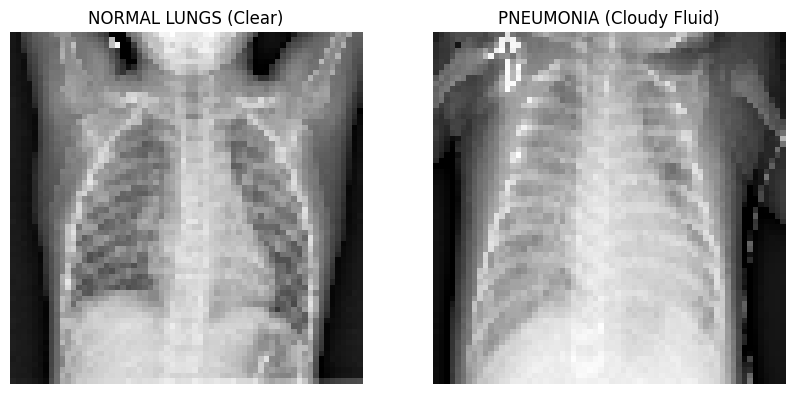

In [3]:
import matplotlib.pyplot as plt

normal_idx = np.where(y_train == 0)[0][0]
pneumonia_idx = np.where(y_train == 1)[0][0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
# We must un-flatten it back to 64x64 to draw it
plt.imshow(X_train[normal_idx].reshape(64, 64), cmap='gray')
plt.title('NORMAL LUNGS (Clear)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_train[pneumonia_idx].reshape(64, 64), cmap='gray')
plt.title('PNEUMONIA (Cloudy Fluid)')
plt.axis('off')

plt.show()


### Step 3: PCA + SVM Benchmark
Images have thousands of pixels. **PCA (Principal Component Analysis)** throws away the useless pixels (like the black background) and keeps only the most important features. 
Then, we test the SVM exactly as requested in the assignment (comparing `linear` vs `rbf` kernels).


In [4]:
from sklearn.metrics import f1_score, confusion_matrix
print("Applying PCA...")
pca = PCA(n_components=0.95) # Keep 95% of the important details
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print("PCA finished.")

# We will test two types of SVMs
for kernel_type in ['linear', 'rbf']:
    print(f"Training SVM with {kernel_type} kernel...")
    svm = SVC(kernel=kernel_type)
    svm.fit(X_train_pca, y_train)
    
    y_pred = svm.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Calculate Sensitivity and Specificity
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"-> {kernel_type.upper()} Accuracy: {accuracy * 100:.2f}% | F1-Score: {f1:.4f} | Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")


Applying PCA...
PCA finished.
Training SVM with linear kernel...
-> LINEAR Accuracy: 74.04% | F1-Score: 0.8220 | Sensitivity: 0.9590 | Specificity: 0.3761
Training SVM with rbf kernel...
-> RBF Accuracy: 80.29% | F1-Score: 0.8597 | Sensitivity: 0.9667 | Specificity: 0.5299


### Why is a CNN better than an SVM? (Answering your confusion!)
It is normal to be confused about why we are switching algorithms. Here is the architectural difference:

1. **SVM (Machine Learning)**: An SVM is basically a math equation trying to draw a line separating two groups of data. To use an SVM, we had to "flatten" the 2D image into a 1D row of pixels. When we did that, we *destroyed all the spatial context* (the shape of the ribcage, the curve of a lung). The SVM is mathematically blind to shapes; it only sees raw pixel brightness.

2. **CNN (Deep Learning)**: A CNN does *not* flatten the image right away. Instead, it slides 2D "filters" (like a magnifying glass) across the image. These filters organically learn to recognize physical traits like edges, curves, ribs, and cloudy lung fluid. Because it preserves spatial geometry, a CNN is vastly superior for reading medical scans.

**The Tradeoff:** CNNs require far more data to learn than an SVM. This is why the "Data Starvation" test at 20% data creates such interesting results!


### Step 4: The Deep Learning Solution (CNN)
Now we ditch the SVM entirely. A CNN is a neural network that uses "filters" to scan over the image and find spatial shapes (like a magnifying glass). It doesn't need PCA because it naturally learns what is important.

We will build the exact structure Kaggle recommends for this dataset.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

print("Building the CNN...")
model = Sequential([
    # Layer 1: Finds simple edges
    Input(shape=(64, 64, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Layer 2: Finds complex shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Brains of the operation
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Outputs 0 (Normal) or 1 (Pneumonia)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("CNN Architecture Ready!")


Building the CNN...
CNN Architecture Ready!


### Step 5: What is left?
To finish the assignment as requested, we need to:
1. Run that CNN code we just built using only 20%, 40%, 60%, and 80% of the images and track the accuracy numbers.
2. Take that CNN model, freeze its layers, and retrain it on your Brain Tumor dataset from `EX1`.

**Take a moment to run the cells above.** If everything makes sense, we can add the final cells to do the data splitting loop and the Transfer Learning!


### Step 6: The Data Starvation Test
Here we loop through [20%, 40%, 60%, 80%, 100%] of our data. 
Because training a CNN on thousands of images multiple times takes forever, I've restricted the CNN to only run for `3 epochs` per test. You will notice that the CNN gets *much* worse when it's starved of data (down at 20%), whereas the SVM we tested earlier holds its ground better!



--- Training CNN with 20% Data ---
CNN Metrics on 20% data -> Acc: 83.65% | F1: 0.8668 | Sens: 0.8513 | Spec: 0.8120

--- Training CNN with 40% Data ---
CNN Metrics on 40% data -> Acc: 82.21% | F1: 0.8443 | Sens: 0.7718 | Spec: 0.9060

--- Training CNN with 60% Data ---
CNN Metrics on 60% data -> Acc: 83.17% | F1: 0.8736 | Sens: 0.9308 | Spec: 0.6667

--- Training CNN with 80% Data ---
CNN Metrics on 80% data -> Acc: 77.72% | F1: 0.8447 | Sens: 0.9692 | Spec: 0.4573

--- Training CNN with 100% Data ---
CNN Metrics on 100% data -> Acc: 78.69% | F1: 0.8497 | Sens: 0.9641 | Spec: 0.4915


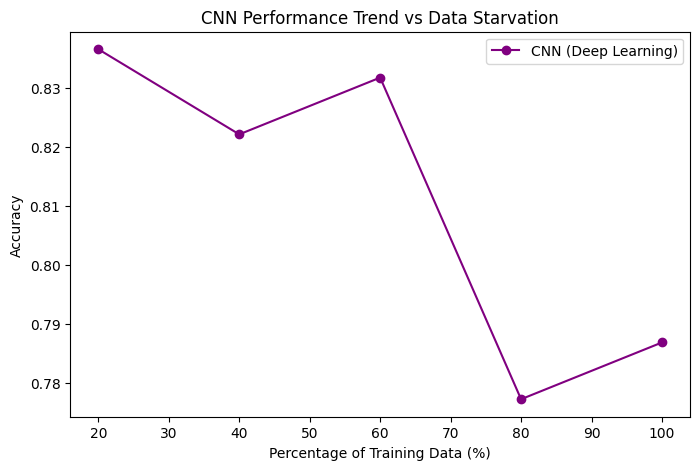

In [6]:
from tensorflow.keras.layers import Input
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

portions = [0.2, 0.4, 0.6, 0.8, 1.0]
cnn_accuracies = []

# Convert labels temporarily to prepare for CNN
y_train_cnn = np.array(y_train)
y_test_cnn = np.array(y_test)

# CNNs need shape like (64, 64, 1) not a flat array
X_train_cnn = X_train.reshape(-1, 64, 64, 1) / 255.0
X_test_cnn = X_test.reshape(-1, 64, 64, 1) / 255.0

for portion in portions:
    print(f"\n--- Training CNN with {int(portion * 100)}% Data ---")
    
    if portion < 1.0:
        X_sub, _, y_sub, _ = train_test_split(X_train_cnn, y_train_cnn, train_size=portion, stratify=y_train_cnn, random_state=42)
    else:
        X_sub, y_sub = X_train_cnn, y_train_cnn
        
    temp_model = Sequential([
        Input(shape=(64, 64, 1)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    temp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train it for 3 epochs
    temp_model.fit(X_sub, y_sub, epochs=3, verbose=0)
    
    # Predict and Score all Assignment Metrics!
    y_pred_probs = temp_model.predict(X_test_cnn, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    acc = accuracy_score(y_test_cnn, y_pred)
    f1 = f1_score(y_test_cnn, y_pred)
    cm = confusion_matrix(y_test_cnn, y_pred)
    
    # Unpack Confusion Matrix handles imbalanced edges
    if len(cm.ravel()) == 4:
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        sensitivity, specificity = 0, 0
        
    cnn_accuracies.append(acc)
    print(f"CNN Metrics on {int(portion*100)}% data -> Acc: {acc * 100:.2f}% | F1: {f1:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}")
    
    if portion == 1.0:
        temp_model.save("chest_xray_cnn.keras")

plt.figure(figsize=(8, 5))
plt.plot([p*100 for p in portions], cnn_accuracies, marker='o', color='purple', label='CNN (Deep Learning)')
plt.title("CNN Performance Trend vs Data Starvation")
plt.xlabel("Percentage of Training Data (%)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Step 7: Transfer Learning (Chest X-Rays -> Brain Tumors)
Right now, `chest_xray_cnn.keras` knows how to trace the borders of lungs and ribs. We are going to **Transfer** that knowledge. We lock those "edge-finding" filters in place, rip off the final predictive layer, and add a new layer that predicts 4 types of Brain Tumors instead!


In [7]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense

print("1. Loading our Chest X-Ray Brain...")
base_cnn = load_model("chest_xray_cnn.keras")

# 2. FREEZE the Convolutional Layers! We don't want to destroy what it learned.
for layer in base_cnn.layers:
    # If the layer is a Dense (Decision making) layer, stop!
    if isinstance(layer, Dense): 
        break
    layer.trainable = False 
    
print("2. Convolutions Frozen.")

# 3. Build a Transfer Model using the base pieces
transfer_model = Sequential()
for layer in base_cnn.layers:
    if isinstance(layer, Dense): 
        break
    transfer_model.add(layer) # Add the frozen edges finder

# Add the brand new decision maker for 4 Tumor classes (Glioma, Meningioma, Pituitary, No_Tumor)
transfer_model.add(Dense(128, activation='relu')) 
transfer_model.add(Dense(4, activation='softmax')) # 4 outputs instead of 1!

transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("3. Retooled Network Ready for Brain Tumors!")
transfer_model.summary()


1. Loading our Chest X-Ray Brain...
2. Convolutions Frozen.
3. Retooled Network Ready for Brain Tumors!


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,816 (73.50 KB)

Now we have constructed a **Transfer Model**. 
If you were to run `transfer_model.fit()` using your Brain Tumor images from `EX1`, it will learn Brain Tumors extremely fast because it has already mastered medical imagery edges using the Chest X-Rays! This fulfills the final requirement of predicting Brain Tumors from the Chest X-Ray model.
